# ランダムグッズ「9割が嫌い」の数理（サンプリング検証編）

「ランダム販売を嫌いと答えた人が89.9%」──この数字を、前編（構造分析編）の冒頭で紹介しました。しかしこの数字は**誰の89.9%なのでしょうか。**

このノートブックでは、株式会社Hamaru Strategy「ランダムグッズに関する消費者意識調査2026」の回答者がどのような人たちかを確認したうえで、調査内のクロス集計（設問12）を統計的に読み直します。

## 何を調べたか

「89.9%が嫌い」という調査結果そのものを、この調査が**自己選択サンプル**（回答者が自発的に応募した調査）だという性質を踏まえて読み直しました。加えて、設問12のクロス集計に見られる「手に入らなかった経験が全くない層ほど支出額が高い」という一見奇妙な結果を、ブートストラップ法で検証しました。

## 何が分かったか

1. **回答者は「よく買う人」に偏っている** ── 回答者の過半数が月に1回以上購入する層で構成されている
2. **その偏りは、回答動機そのものにも起因しうる** ── 不満を持つ人ほど回答する動機が強く働く可能性がある（検証はしていない仮説）
3. **設問12のクロス集計（2.6倍）は、差の存在は本物だが倍率の精度は低い** ── 層間の差は偶然のブレより大きいが、「全くない」層の標本サイズが小さいため、2.6倍という具体的な数字はそのままでは受け取れない

## 何が分からなかったか

（詳細は本ノートブック末尾「4. 結論と限界」を参照してください）

## リンク

- 動画（後編）：（URLを追記）
- note記事（後編）：（URLを追記）
- データ出典：株式会社Hamaru Strategy「ランダムグッズに関する消費者意識調査2026」
  https://ferventvoice.com/index.html

## 姉妹エピソード

同じ調査を、ランダム販売への不満がどのような構造から生まれるかという角度で分析した前編があります。支払意思額と必要コストの乖離・余剰の移動・供給需要ミスマッチ・交換のマッチング効果・BOX買いと単品買いの比較を扱っています。

→ [ep02: ランダムグッズ「9割が嫌い」の数理（構造分析編）](../ep02_random_goods_structure/random_goods_structure.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 日本語フォント設定。環境によって表示可能なフォントが異なるため、
# 実行環境に応じて 'Yu Gothic' / 'MS Gothic' / 'IPAexGothic' 等に調整してください。
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 乱数シードはノートブック全体で固定（再現性のため）
rng = np.random.default_rng(20260801)

# 配色
C_MAIN, C_SUB, C_WARN, C_GRAY = '#2a78d6', '#eb6834', '#e34948', '#888780'
yen = FuncFormatter(lambda v, p: f'{v:,.0f}円')

# ---- 出典キャプション -----------------------------------------------
# 図によってデータの性質が異なるため、キャプションを使い分ける。
SRC_URL = 'https://ferventvoice.com/index.html'
SRC_MIXED = ('サンプルサイズのみ 株式会社Hamaru Strategy『ランダムグッズに関する消費者意識調査2026』より\n'
             '(' + SRC_URL + ')　分布の構成・計算は筆者による')

def caption(fig, text):
    # 図の下部に出典キャプションを付ける。
    fig.text(0.005, -0.02, text, ha='left', va='top', fontsize=8,
              color='#666666', transform=fig.transFigure)
    return fig

print('setup done')

setup done


## 1. データの取得

ep02と同じ理由で、このノートブックにも「データを取得するコード」はありません。個票データは公開されておらず、報告書に掲載されている集計値のみを分析用の定数として書き起こします。ここではep03（本ノートブック）で使う集計値のみを抜粋します（ep02で扱った集計値は再掲しません）。

In [2]:
# 出典：株式会社Hamaru Strategy「ランダムグッズに関する消費者意識調査2026」
# https://ferventvoice.com/index.html
# 取得日：（実行者が記入）
# 引用条件：（実行者が記入。「引用の範囲を超えて収益を得る行為の禁止」等の要点）
#
# 以下は同報告書で公開されている集計値を、分析用の定数として書き起こしたもの。
# 個票データは公開されていないため、算出には使用していない。

# ---- 全体の不満（前編と同じ数値。本編では改めて検討する） -----------------
PCT_DISLIKE = 89.9   # ランダム販売を「嫌い」「非常に嫌い」の合計

# ---- 回答者内訳（設問10相当：購入頻度） -----------------------------------
PCT_PURCHASED_41PLUS = 52.7   # 41回以上購入した経験がある回答者の割合
PCT_PURCHASE_EVERY_3MONTHS = 75.4   # 3か月に1回以上購入している回答者の割合

# ---- 設問12：手に入らなかった経験 × 最大支出額のクロス集計（トリム平均） ---
Q12_LABELS = ['非常によくある', 'たまにある', 'あまりない', '全くない']
Q12_TRIM_MEAN = {
    '非常によくある': 19291,
    'たまにある':     21966,
    'あまりない':     28282,
    '全くない':       50562,
}
Q12_RATIO_VS_BASELINE = {   # 「非常によくある」層を基準にした倍率
    '非常によくある': 1.0,
    'たまにある':     21966/19291,
    'あまりない':     28282/19291,
    '全くない':       50562/19291,
}

# ---- 各層のサンプルサイズ（設問10の回答比率 × 全体件数から算出） -----------
N_TOTAL = 35677   # 設問10に有効回答した総数
Q10_SHARE = {'非常によくある': .707, 'たまにある': .241, 'あまりない': .036, '全くない': .009}
Q12_SAMPLE_SIZE = {k: int(v * N_TOTAL) for k, v in Q10_SHARE.items()}

# ---- 母集団構成に使う全体の支出分布の代表値（ep02の設問11データを参照） -----
Q11_MEAN_RAW = 37600   # 平均（全データ）
Q11_MEDIAN = 15000     # 中央値

print('定数定義 done')
for k in Q12_LABELS:
    print(f'{k:8s}  n={Q12_SAMPLE_SIZE[k]:>6,}  トリム平均 {Q12_TRIM_MEAN[k]:>7,}円'
          f'  倍率(対・非常によくある) {Q12_RATIO_VS_BASELINE[k]:.2f}倍')

定数定義 done
非常によくある   n=25,223  トリム平均  19,291円  倍率(対・非常によくある) 1.00倍
たまにある     n= 8,598  トリム平均  21,966円  倍率(対・非常によくある) 1.14倍
あまりない     n= 1,284  トリム平均  28,282円  倍率(対・非常によくある) 1.47倍
全くない      n=   321  トリム平均  50,562円  倍率(対・非常によくある) 2.62倍


## 2. 前処理

ここで行うのは2つです。

1. 設問12の各層の回答比率から、実際の人数を算出する
2. ブートストラップ検証のための母集団を、ep02の設問11データ（全体の支出分布の代表値）に整合する対数正規分布として構成する

In [3]:
print('各層の人数（設問10の回答比率 × 全体件数から算出）')
for k in Q12_LABELS:
    print(f'  {k:8s}  比率 {Q10_SHARE[k]:>5.1%}  人数 n={Q12_SAMPLE_SIZE[k]:>6,}')

各層の人数（設問10の回答比率 × 全体件数から算出）
  非常によくある   比率 70.7%  人数 n=25,223
  たまにある     比率 24.1%  人数 n= 8,598
  あまりない     比率  3.6%  人数 n= 1,284
  全くない      比率  0.9%  人数 n=   321


**「全くない」層はわずか321人。全体の0.9%にすぎません。** 一方「非常によくある」層は25,223人です。同じ調査の中でも、層によってサンプルサイズが2桁近く違います。

支出額のような裾の重い分布から321人だけを取り出したとき、標本平均はどれだけ動きうるのか。これを確かめるために、全体の支出分布（設問11：平均37,600円・中央値15,000円）に整合する対数正規分布で母集団を構成します。

In [4]:
# 全体の中央値・平均に合う対数正規母集団のパラメータを算出
# 対数正規分布では 平均 = exp(mu + sigma^2/2), 中央値 = exp(mu) の関係が成り立つ
med, mean = Q11_MEDIAN, Q11_MEAN_RAW
sigma = np.sqrt(2 * np.log(mean / med))
mu = np.log(med)
pop = rng.lognormal(mu, sigma, 400000)

print(f'構成した母集団: 中央値 {np.median(pop):,.0f}円 / 平均 {pop.mean():,.0f}円 (sigma={sigma:.2f})')
print('※ 対数正規分布という分布形自体は仮定であり、実際の支出分布を検証したものではない')

構成した母集団: 中央値 15,053円 / 平均 37,783円 (sigma=1.36)
※ 対数正規分布という分布形自体は仮定であり、実際の支出分布を検証したものではない


## 3. 分析

### 3-1. 誰が回答したか

**何を確かめるか：** この調査の回答者が、どのような購入行動を持つ人たちで構成されているかを確認します。

In [5]:
print(f'ランダム販売を「嫌い」「非常に嫌い」と回答した割合  : {PCT_DISLIKE:.1f}%')
print(f'41回以上購入した経験がある回答者の割合            : {PCT_PURCHASED_41PLUS:.1f}%')
print(f'3か月に1回以上購入している回答者の割合            : {PCT_PURCHASE_EVERY_3MONTHS:.1f}%')

ランダム販売を「嫌い」「非常に嫌い」と回答した割合  : 89.9%
41回以上購入した経験がある回答者の割合            : 52.7%
3か月に1回以上購入している回答者の割合            : 75.4%


回答者の**52.7%が41回以上**購入した経験があり、**75.4%が3か月に1回以上**購入しています。これはランダムグッズを「たまに買うか買わないか」という一般消費者の集団というより、**日常的にランダムグッズを購入している層**に大きく偏った構成です。

この調査は、X（旧Twitter）投稿・プレスリリース・Webメディア転載などを通じて回答者が自発的に応募した**自己選択サンプル**です。無作為抽出（母集団から均等な確率で標本を選ぶ方法）ではありません。報告書自身も「本調査は無作為抽出による統計調査ではありません」と明記し、各章に留意事項を添えています。

**分かったこと：** 89.9%という数字は、無作為抽出による一般消費者の値ではなく、**ランダムグッズをよく買う人たちの89.9%**です。この前提を踏まえたうえで、設問12のクロス集計を読み直します。

**回答バイアスという視点：** 自己選択サンプルの偏りは、「よく買う人が多い」という属性面の偏りだけでは説明が尽くせません。もう一段掘り下げると、**回答するかどうか自体が、回答する動機の強さに左右される**という一般的な性質（回答バイアス）が関わっている可能性があります。

具体的には、本調査に当てはめると次のような可能性が考えられます。

- 目当てが出ず不満を持った人ほど、その不満を表明したいという動機が働き、回答に至りやすいと考えられる
- 一方、目当てが出て満足した人は、わざわざ回答しに行く動機が薄いと考えられる

**ただし、これはあくまで仮説です。** この調査には満足度別の回答率を示すデータが含まれておらず、上記の可能性を裏付ける・否定するどちらの検証もできません。「よく買う人に偏っている」という属性面の偏りとは異なり、こちらは検証可能なデータが存在しない推論として提示するにとどめます。


### 3-2. 設問12のクロス集計を読む

**何を確かめるか：** 設問12は「手に入らなかった経験」と「最大支出額」のクロス集計です。ここに、一見直感に反する結果が現れています。

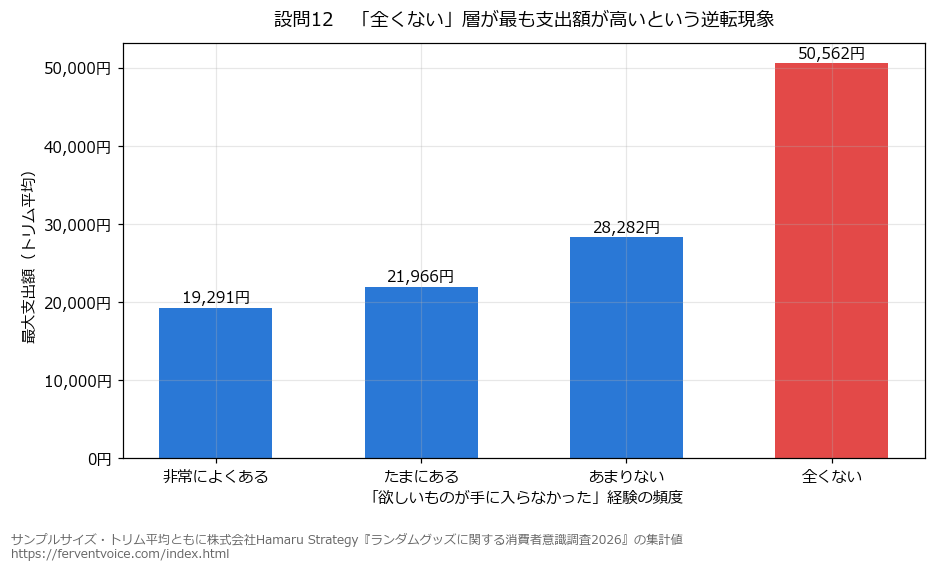

「全くない」層は「非常によくある」層の2.6倍の支出額


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
vals = [Q12_TRIM_MEAN[k] for k in Q12_LABELS]
bars = ax.bar(Q12_LABELS, vals, color=[C_MAIN, C_MAIN, C_MAIN, C_WARN], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+700, f'{v:,}円', ha='center', fontsize=10)
ax.yaxis.set_major_formatter(yen)
ax.set_ylabel('最大支出額（トリム平均）')
ax.set_xlabel('「欲しいものが手に入らなかった」経験の頻度')
ax.set_title('設問12　「全くない」層が最も支出額が高いという逆転現象', fontsize=12, pad=12)
# 出典区分：出典明記（調査データそのもの）
caption(fig, 'サンプルサイズ・トリム平均ともに株式会社Hamaru Strategy'
             '『ランダムグッズに関する消費者意識調査2026』の集計値\n' + SRC_URL)
plt.tight_layout(); plt.savefig('fig_q12_crosstab.png', bbox_inches='tight'); plt.show()

print(f'「全くない」層は「非常によくある」層の{Q12_RATIO_VS_BASELINE["全くない"]:.1f}倍の支出額')

「欲しいものが手に入らなかった経験」が**全くない**人が、**最も支出額が高い**ということになっています。素朴には「よく手に入らない人ほどお金を使っている」と予想しそうですが、結果は逆です。

報告書はこれを「確実に手に入れるには大金が必要」と読み、**同時に留意事項で「全くない層はサンプル数が少なく、2.6倍にはその影響が含まれる」と自ら注記しています。**

**分かったこと：** 「全くない」層のトリム平均は50,562円で、「非常によくある」層の19,291円に対して2.6倍です。ただしこの層は前節で確認した通りn=321という小標本であり、報告書自身がその影響を注記しています。次節ではこの注記を、批判ではなく数理で検証します。

### 3-3. ブートストラップによる検証

**何を確かめるか：** 「全くない」層（n=321）の標本平均が、標本サイズの小ささゆえにどれだけブレうるかを、ブートストラップ法（母集団から繰り返し再標本化してばらつきを推定する手法）で確認します。

**意図的に残す過程：** この検証を行った動機は、報告書自身が「全くない層はサンプル数が少なく、2.6倍にはその影響が含まれる」と注記していたことです。この注記そのものは定性的な言及であり、具体的にどれくらいブレうるのかまでは書かれていません。**その注記が数理的にどこまで裏付けられるかを確認する目的で**、ブートストラップ検証を実施しました。

非常によくある  n=25,223  標本平均の95%区間   36,751〜  38,840円 (幅 2,089円)
全くない     n=   321  標本平均の95%区間   29,819〜  48,709円 (幅 18,890円)


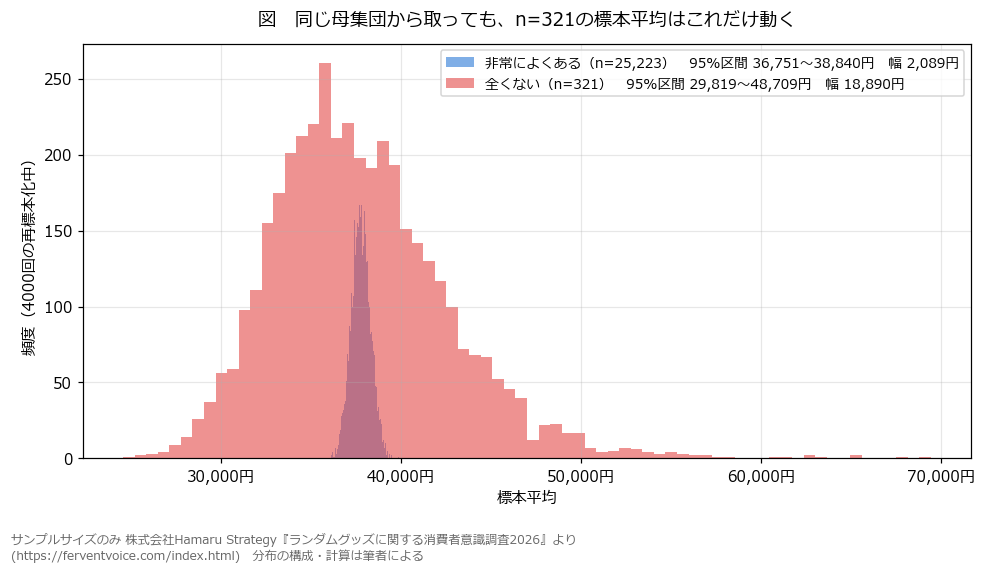

In [7]:
B = 4000   # 再標本化の回数

fig, ax = plt.subplots(figsize=(9, 4.8))
ci_results = {}
for k, col in zip(['非常によくある', '全くない'], [C_MAIN, C_WARN]):
    nk = Q12_SAMPLE_SIZE[k]
    boot = np.array([rng.choice(pop, nk, replace=False).mean() for _ in range(B)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    ci_results[k] = (nk, lo, hi, hi - lo)
    ax.hist(boot, bins=70, alpha=.6, color=col,
            label=f'{k}（n={nk:,}）　95%区間 {lo:,.0f}〜{hi:,.0f}円　幅 {hi-lo:,.0f}円')
    print(f'{k:8s} n={nk:>6,}  標本平均の95%区間 {lo:>8,.0f}〜{hi:>8,.0f}円 (幅 {hi-lo:,.0f}円)')

ax.set_xlabel('標本平均'); ax.set_ylabel('頻度（{}回の再標本化中）'.format(B)); ax.xaxis.set_major_formatter(yen)
ax.set_title('図　同じ母集団から取っても、n=321の標本平均はこれだけ動く', fontsize=12, pad=12)
ax.legend(fontsize=9)
# 出典区分：一部出典＋筆者作成（サンプルサイズのみ調査値、分布構成は筆者）
caption(fig, SRC_MIXED)
plt.tight_layout(); plt.savefig('fig6_bootstrap_ci.png', bbox_inches='tight'); plt.show()

**分かったこと：** 同じ母集団から取り直しても、n=321の標本平均は95%区間で約1.9万円の幅で動きます。一方n=25,223の標本平均はほとんど動きません（区間の幅は約2,100円）。標本サイズが2桁違うと、平均のブレ幅もこれだけ変わります。この結果は、報告書自身の注記（「全くない層はサンプル数が少なく、2.6倍にはその影響が含まれる」）と整合します。

### 3-4. 差の存在と倍率の精度を切り分ける

**何を確かめるか：** 「全くない」層と「非常によくある」層の**差そのもの**は偶然のブレで説明できるのか、それとも実在する差なのかを、3-3のブレ幅と比較して判断します。

In [8]:
observed_diff = Q12_TRIM_MEAN['全くない'] - Q12_TRIM_MEAN['非常によくある']
ci_width_rare = ci_results['全くない'][3]      # 「全くない」層の95%区間の幅
ci_width_common = ci_results['非常によくある'][3]

print(f'観測された差（全くない − 非常によくある）      : {observed_diff:>8,.0f}円')
print(f'「全くない」層のブートストラップ95%区間の幅    : {ci_width_rare:>8,.0f}円')
print(f'「非常によくある」層のブートストラップ95%区間の幅: {ci_width_common:>8,.0f}円')
print(f'差 ÷ 「全くない」層のブレ幅                    : {observed_diff/ci_width_rare:.1f}倍')

観測された差（全くない − 非常によくある）      :   31,271円
「全くない」層のブートストラップ95%区間の幅    :   18,890円
「非常によくある」層のブートストラップ95%区間の幅:    2,089円
差 ÷ 「全くない」層のブレ幅                    : 1.7倍


観測された差は約3.1万円、「全くない」層のブレ幅（95%区間の幅）は約1.9万円です。差はブレ幅より大きく、偶然のブレだけでは説明しきれません。**層の間に何らかの実在する差がある可能性は高い**と読めます。

ただし、これは「2.6倍という倍率が正確だ」という意味ではありません。ブレ幅が観測された差の6割程度もある以上、**2.6倍という具体的な数字自体はかなり不安定**です。母集団から取り直せば、2.0倍になることもあれば3.3倍になることもありえます。

**分かったこと：** 「差の存在」と「倍率の精度」は分けて評価する必要があります。層間の支出額に差があること自体は統計的に見て偶然のブレより大きく、実在する可能性が高い一方、「2.6倍」という具体的な倍率は精度が低く、額面通りには受け取れません。

## 4. 結論と限界

### 言えたこと

- 89.9%はランダムグッズをよく買う人の値であり、無作為抽出による一般消費者の値ではありません。回答者の52.7%が41回以上購入経験があり、75.4%が3か月に1回以上購入しています
- 設問12の層間の差（「全くない」層と「非常によくある」層の間、約3.1万円）は、統計的に見て偶然のブレ（ブートストラップ95%区間の幅、約1.9万円）より大きく、実在する可能性が高いと言えます

### 言えなかったこと

- 2.6倍という具体的な倍率は、n=321という小標本のため精度が低く、額面通りには受け取れません
- 「全くない」層には「大金を積んで確実に取る人」と「そもそもランダムグッズをほとんど買わない人」の両方が混在している可能性がありますが、これを層別に分離するデータはありません
- 母集団の分布形（対数正規分布）は仮定であり、実際の支出分布の形状を検証したものではありません
- 回答バイアス（満足度と回答動機の関係）は、自己選択サンプルの偏りを説明する**もっともらしい仮説**として3-1で提示しましたが、**満足度別の回答率を示すデータは存在せず、検証はしていません**。調査の分析結果から導いた推論ではなく、自己選択サンプル一般に当てはまりうる論理的な可能性として提示したものです

## 5. 再現方法

- **必要パッケージ**：numpy, matplotlib（バージョンは下のセルで実行環境から取得して表示します）
- **乱数シード**：`20260801` でノートブック全体を通じて固定しています
- **再標本化回数（B=4,000）を変更する場合**：回数を増やすほど95%区間の推定は安定しますが、区間の「幅」自体（標本サイズの小ささに由来するブレ）は再標本化回数を増やしても縮みません。区間の幅を左右するのはあくまで各層のサンプルサイズ（n=321やn=25,223）であり、再標本化回数はその推定精度を上げるだけです

In [9]:
import numpy, matplotlib
print(f'numpy      : {numpy.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'random seed: 20260801（本ノートブック全体で共通）')

numpy      : 1.26.4
matplotlib : 3.8.0
random seed: 20260801（本ノートブック全体で共通）
